In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, 
                             classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Load processed dataset
df = pd.read_csv(r"C:\Users\mages\capstone\smartcrop-system\data\processed\smartcrop_features.csv")

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nTarget distribution:")
print(df['crop_failure_risk'].value_counts())

Shape: (1934, 10)

First 3 rows:
          N         P     K  temperature  humidity        ph  rainfall  \
0  0.071429  0.000000  0.00     0.341556  0.899481  0.671669  0.332938   
1  0.200000  0.378571  0.38     0.230424  0.026661  0.416677  0.262366   
2  0.200000  0.435714  0.09     0.351273  0.116622  0.387982  0.360644   

         label  crop_failure_risk  crop_encoded  
0       orange                  0            16  
1     chickpea                  0             3  
2  kidneybeans                  0             9  

Target distribution:
crop_failure_risk
0    967
1    967
Name: count, dtype: int64


In [14]:
# Define features and target
features = ['N', 'P', 'K', 'temperature', 
            'humidity', 'ph', 'rainfall']

X = df[features]
y = df['crop_failure_risk']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,    # 80% train, 20% test
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training samples: 1547
Testing samples: 387

Training target distribution:
crop_failure_risk
1    786
0    761
Name: count, dtype: int64


In [15]:
# Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Safe', 'High Risk']))

✅ Model trained successfully!

Model Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       206
   High Risk       1.00      1.00      1.00       181

    accuracy                           1.00       387
   macro avg       1.00      1.00      1.00       387
weighted avg       1.00      1.00      1.00       387



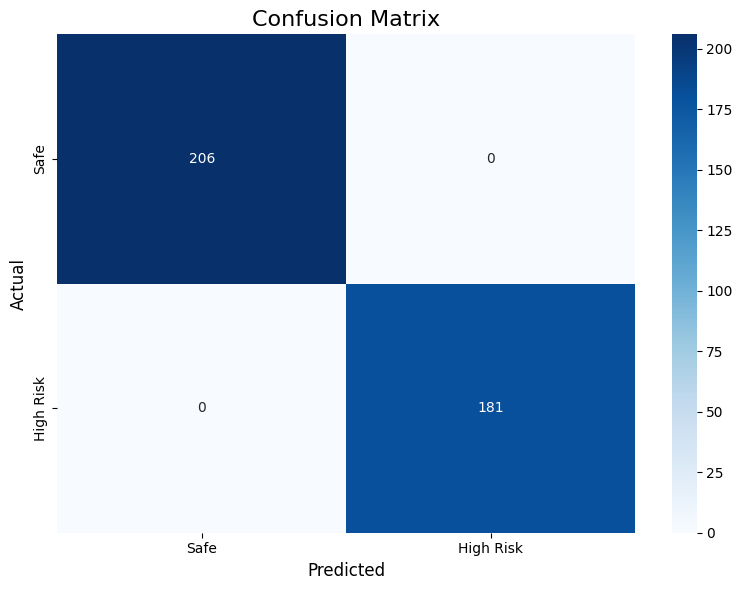

Saved!


In [16]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'High Risk'],
            yticklabels=['Safe', 'High Risk'])
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\mages\capstone\smartcrop-system\docs\confusion_matrix.png")
plt.show()
print("Saved!")

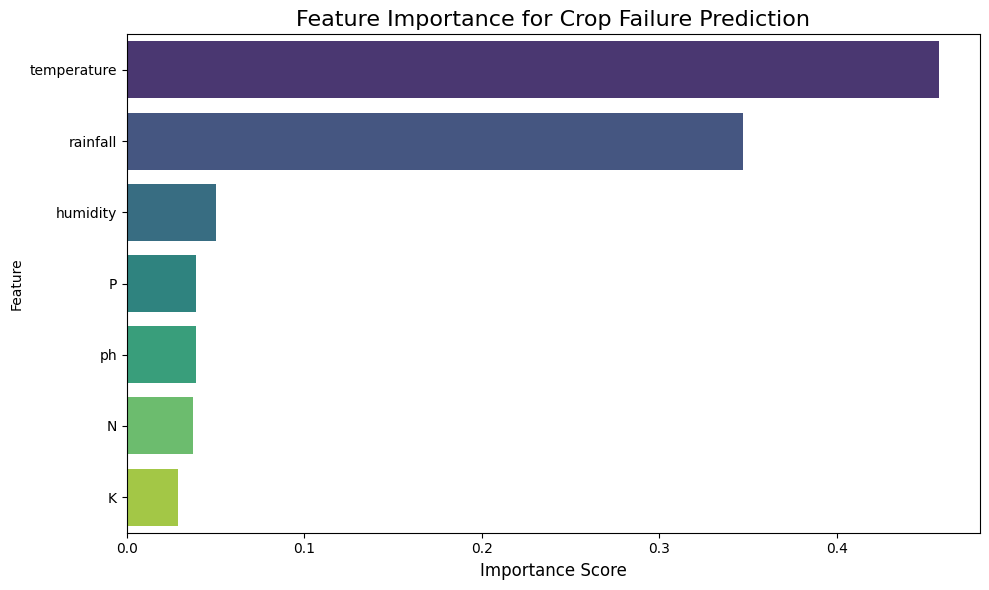


Feature Rankings:
       Feature  Importance
3  temperature    0.457868
6     rainfall    0.347284
4     humidity    0.050280
1            P    0.039141
5           ph    0.038867
0            N    0.037453
2            K    0.029108


In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', 
            data=importance, 
            hue='Feature',      # ← add this
            legend=False,       # ← add this
            palette='viridis')
plt.title('Feature Importance for Crop Failure Prediction',
          fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\mages\capstone\smartcrop-system\docs\feature_importance.png")
plt.show()
print("\nFeature Rankings:")
print(importance)

In [18]:
def calculate_risk_score(N, P, K, temperature, 
                          humidity, ph, rainfall):
    """
    Calculate crop failure risk score for a farmer
    Returns: risk_score (0-100%), status, advice
    """
    # Fix: use DataFrame with column names instead of plain list
    input_data = pd.DataFrame([[N, P, K, temperature, 
                                 humidity, ph, rainfall]],
                    columns=['N', 'P', 'K', 'temperature', 
                             'humidity', 'ph', 'rainfall'])
    
    # Get probability of failure
    probability = model.predict_proba(input_data)[0][1]
    risk_score = round(probability * 100, 2)
    
    # Determine status
    if risk_score < 30:
        status = "SAFE"
        color = "green"
        advice = "Your crop is healthy. Continue normal farming practices."
    elif risk_score < 60:
        status = "MODERATE RISK"
        color = "yellow"
        advice = "Consider irrigation and soil treatment this week."
    else:
        status = "HIGH RISK"
        color = "red"
        advice = "High failure risk detected! Insurance claim eligibility triggered."
    
    return {
        "risk_score": risk_score,
        "status": status,
        "color": color,
        "advice": advice
    }

# Test with sample farmer data
result = calculate_risk_score(
    N=90, P=42, K=43,
    temperature=40.0,
    humidity=30.0,
    ph=6.5,
    rainfall=20.0
)

print("=== SAMPLE PREDICTION ===")
print(f"Risk Score: {result['risk_score']}%")
print(f"Status: {result['status']}")
print(f"Advice: {result['advice']}")

=== SAMPLE PREDICTION ===
Risk Score: 84.0%
Status: HIGH RISK
Advice: High failure risk detected! Insurance claim eligibility triggered.


In [19]:
import os
os.makedirs(r"C:\Users\mages\capstone\smartcrop-system\models", exist_ok=True)

# Save model
joblib.dump(model, r"C:\Users\mages\capstone\smartcrop-system\models\crop_failure_model.pkl")
print("✅ Model saved to models/crop_failure_model.pkl")

# Verify it loads correctly
loaded_model = joblib.load(r"C:\Users\mages\capstone\smartcrop-system\models\crop_failure_model.pkl")

# Fix: use DataFrame instead of plain list
test_input = pd.DataFrame([[90, 42, 43, 40.0, 30.0, 6.5, 20.0]],
                columns=['N', 'P', 'K', 'temperature', 
                         'humidity', 'ph', 'rainfall'])

test_pred = loaded_model.predict(test_input)
print("✅ Model loads correctly!")
print(f"Test prediction: {'High Risk' if test_pred[0]==1 else 'Safe'}")

✅ Model saved to models/crop_failure_model.pkl
✅ Model loads correctly!
Test prediction: High Risk


In [20]:
# Check what the model learned
print("Risk distribution in dataset:")
print(df['crop_failure_risk'].value_counts())

# Check what probability it gives for our test input
test_input = pd.DataFrame([[90, 42, 43, 40.0, 30.0, 6.5, 20.0]],
                columns=['N', 'P', 'K', 'temperature', 
                         'humidity', 'ph', 'rainfall'])

proba = loaded_model.predict_proba(test_input)
print(f"\nProbability of Safe: {proba[0][0]*100:.2f}%")
print(f"Probability of High Risk: {proba[0][1]*100:.2f}%")

Risk distribution in dataset:
crop_failure_risk
0    967
1    967
Name: count, dtype: int64

Probability of Safe: 16.00%
Probability of High Risk: 84.00%
